<center><h1>Last_First_HW2</h1></center>
<br>
<br>

Name: Juifan Lin
<br>
Github Username: JiaLiiin
<br>
USC ID:9985422205

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

Get the Cycle Power Plant Data Set

In [8]:
df = pd.read_excel('../data/Folds5x2_pp.xlsx', sheet_name='Sheet1')
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [9]:
rows, cols = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")


Number of rows: 9568
Number of columns: 5


Rows represent individual hourly data points collected over 6 years (2006-2011).
Columns represent the ambient features (AT, V, AP, RH) and net hourly electrical energy output (PE)."

#### ii. pairwise scatterplots of all the varianbles

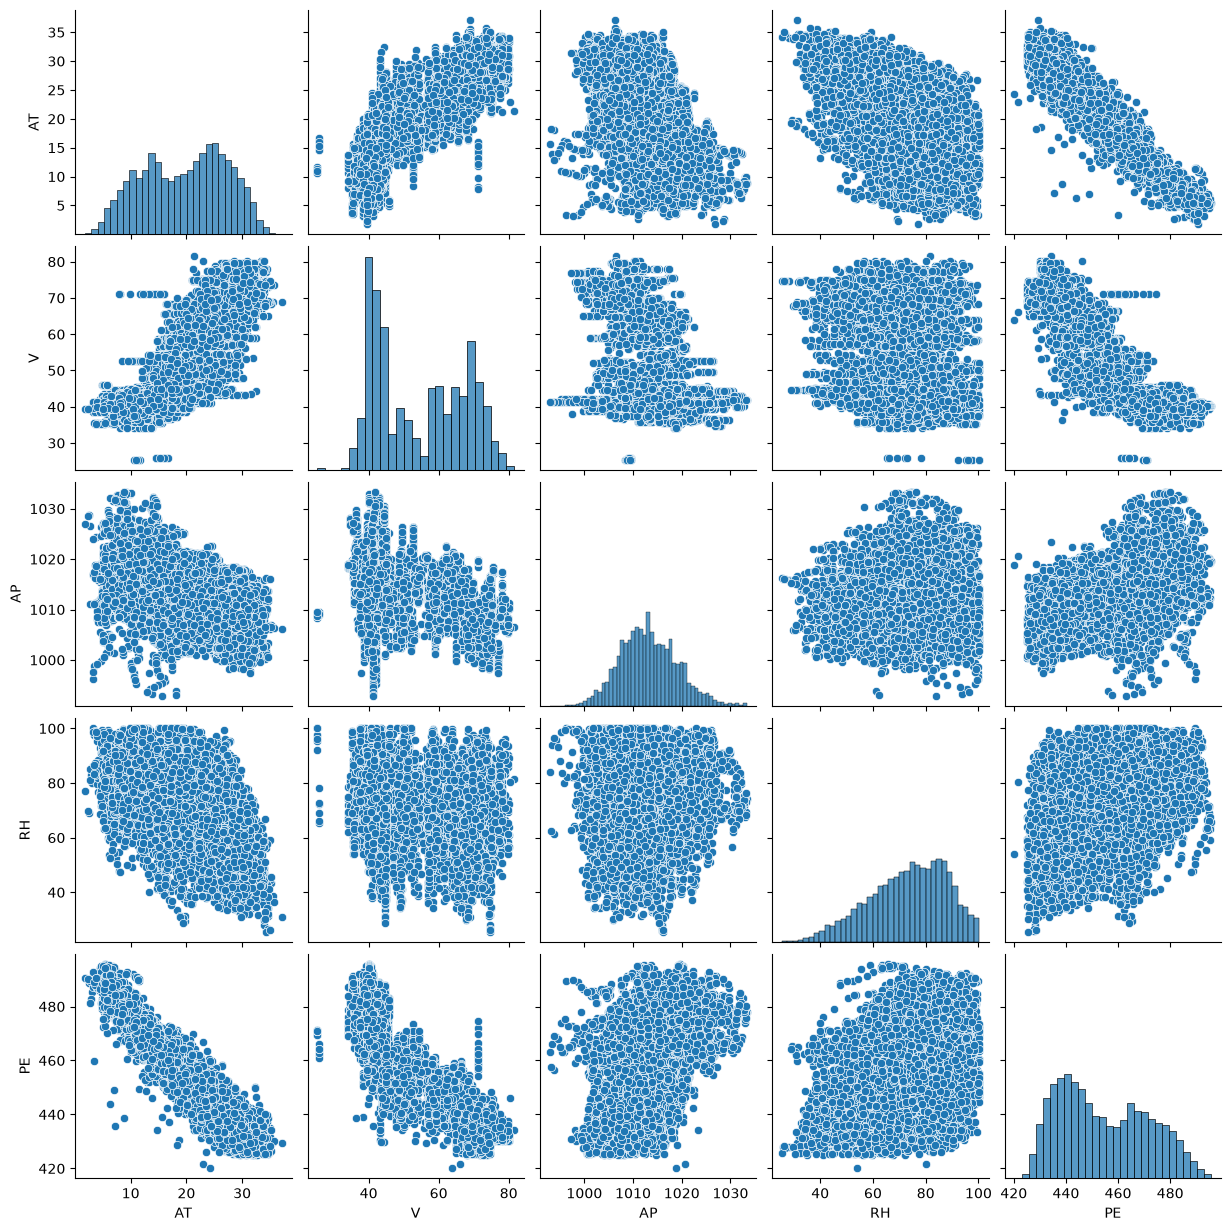

- AT and V show strong negative linear correlations with PE.
- AP and RH show weak to moderate positive correlations with PE.
- AT and V exhibit strong positive linear correlation with each other.


In [10]:
sns.pairplot(df)
plt.show()

print("- AT and V show strong negative linear correlations with PE.")
print("- AP and RH show weak to moderate positive correlations with PE.")
print("- AT and V exhibit strong positive linear correlation with each other.")

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [11]:
stats_df = pd.DataFrame({
    'Mean': df.mean(),
    'Median': df.median(),
    'Range': df.max() - df.min(),
    'Q1': df.quantile(0.25),
    'Q3': df.quantile(0.75),
    'IQR': df.quantile(0.75) - df.quantile(0.25)
})
stats_df

,Mean,Median,Range,Q1,Q3,IQR
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


### (c) Simple Linear Regression

Simple Regression: PE ~ AT
Coefficient: -2.1713, p-value: 0.0000e+00, R2: 0.8989
Statistically significant: Yes (p < 0.05)

Simple Regression: PE ~ V
Coefficient: -1.1681, p-value: 0.0000e+00, R2: 0.7565
Statistically significant: Yes (p < 0.05)

Simple Regression: PE ~ AP
Coefficient: 1.4899, p-value: 0.0000e+00, R2: 0.2688
Statistically significant: Yes (p < 0.05)

Simple Regression: PE ~ RH
Coefficient: 0.4557, p-value: 0.0000e+00, R2: 0.1519
Statistically significant: Yes (p < 0.05)



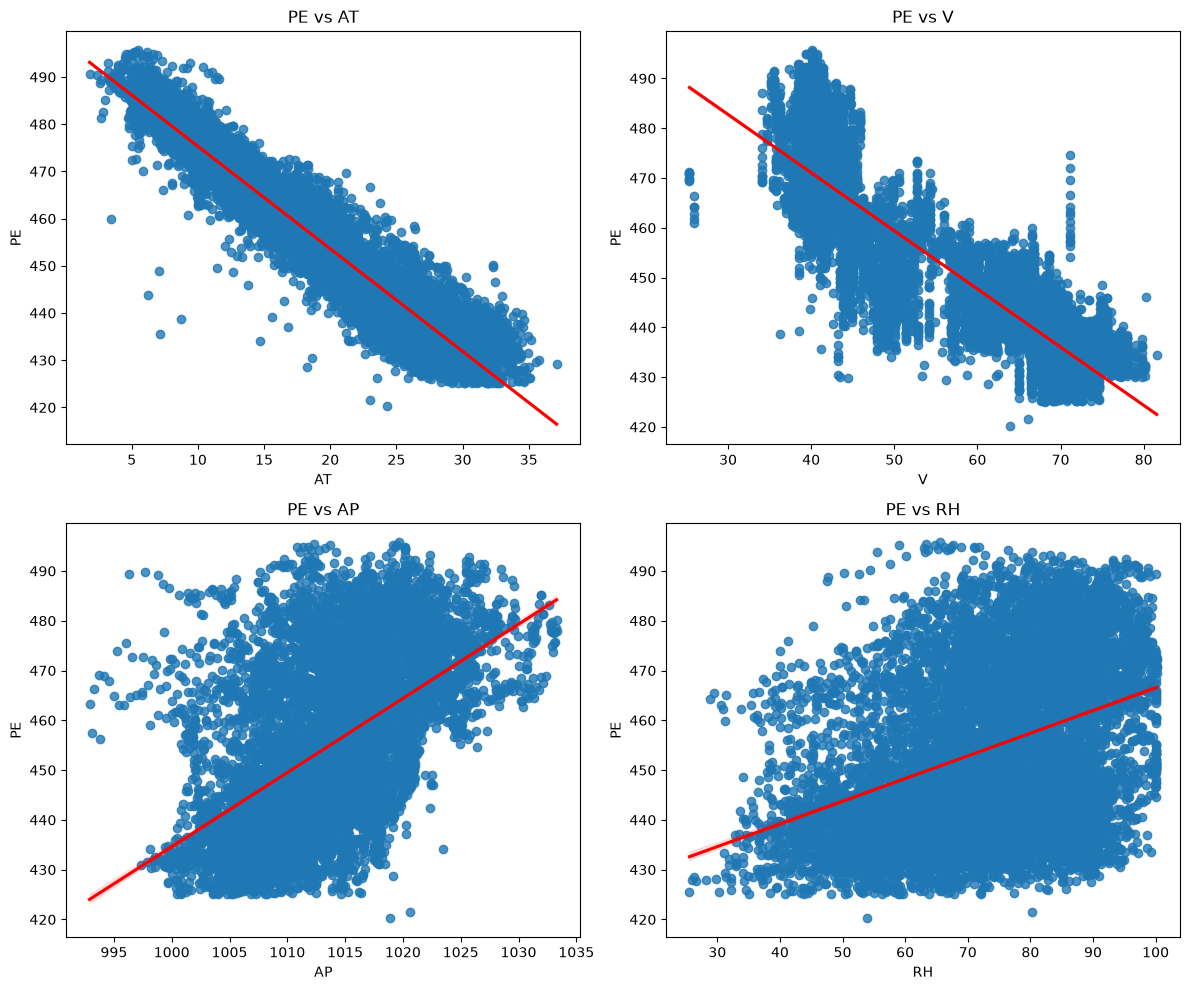

Outlier analysis using Studentized Residuals (>3 or <-3):
Outliers count for AT: 42
Outliers count for V: 33
Outliers count for AP: 29
Outliers count for RH: 2


In [12]:
predictors = ['AT', 'V', 'AP', 'RH']
simple_coeffs = {}
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, pred in enumerate(predictors):
    model = smf.ols(formula=f'PE ~ {pred}', data=df).fit()
    simple_coeffs[pred] = model.params[pred]
    print(f"Simple Regression: PE ~ {pred}")
    print(f"Coefficient: {model.params[pred]:.4f}, p-value: {model.pvalues[pred]:.4e}, R2: {model.rsquared:.4f}")
    print("Statistically significant: Yes (p < 0.05)\n")
    sns.regplot(x=pred, y='PE', data=df, ax=axes[i], line_kws={'color': 'red'})
    axes[i].set_title(f'PE vs {pred}')

plt.tight_layout()
plt.show()
print("Outlier analysis using Studentized Residuals (>3 or <-3):")

for pred in predictors:
    model = smf.ols(formula=f'PE ~ {pred}', data=df).fit()
    infl = model.get_influence()
    outliers = np.where(np.abs(infl.resid_studentized_internal) > 3)[0]
    print(f"Outliers count for {pred}: {len(outliers)}")

### (d) Multiple Regression

In [23]:
multi_model = smf.ols(formula='PE ~ AT + V + AP + RH', data=df).fit()
multi_coeffs = multi_model.params.drop('Intercept')
r_squared = multi_model.rsquared
adj_r_squared = multi_model.rsquared_adj
f_stat = multi_model.fvalue
f_pvalue = multi_model.f_pvalue

print(f"=== Multiple Linear Regression Results ===")
print(f"Model Fit: R-squared = {r_squared:.4f}, Adjusted R-squared = {adj_r_squared:.4f}")
print(f"Overall Model Significance: F-statistic = {f_stat:.2f} (p-value = {f_pvalue:.4e})\n")

print(f"{'Predictor':<10} | {'Coefficient':<12} | {'Std Error':<10} | {'t-statistic':<12} | {'p-value':<10}")

for var in ['Intercept', 'AT', 'V', 'AP', 'RH']:
    coef = multi_model.params[var]
    stderr = multi_model.bse[var]
    tstat = multi_model.tvalues[var]
    pval = multi_model.pvalues[var]
    print(f"{var:<10} | {coef:<12.4f} | {stderr:<10.4f} | {tstat:<12.4f} | {pval:<10.4e}")

print(f"Model Performance: The model explains roughly {r_squared * 100:.2f}% of the variance in Electrical Energy Output (PE).")
print("Temperature (AT): Holding other variables constant, each 1°C increase in temperature reduces energy output by ~1.98 MW.")
print("Exhaust Vacuum (V): Holding other variables constant, each unit increase in vacuum reduces energy output by ~0.23 MW.")
print("Ambient Pressure (AP): Holding other variables constant, each 1 millibar increase in ambient pressure increases energy output by ~0.06 MW.")
print("Relative Humidity (RH): Holding other variables constant, each 1% increase in relative humidity reduces energy output by ~0.16 MW.")
print("We can reject the null hypothesis H0: beta_j = 0 for ALL predictors (AT, V, AP, RH) because all p-values are < 0.05.")

=== Multiple Linear Regression Results ===
Model Fit: R-squared = 0.9287, Adjusted R-squared = 0.9287
Overall Model Significance: F-statistic = 31138.27 (p-value = 0.0000e+00)

Predictor  | Coefficient  | Std Error  | t-statistic  | p-value   
Intercept  | 454.6093     | 9.7485     | 46.6337      | 0.0000e+00
AT         | -1.9775      | 0.0153     | -129.3420    | 0.0000e+00
V          | -0.2339      | 0.0073     | -32.1221     | 4.3753e-215
AP         | 0.0621       | 0.0095     | 6.5641       | 5.5071e-11
RH         | -0.1581      | 0.0042     | -37.9185     | 3.1046e-293
Model Performance: The model explains roughly 92.87% of the variance in Electrical Energy Output (PE).
Temperature (AT): Holding other variables constant, each 1°C increase in temperature reduces energy output by ~1.98 MW.
Exhaust Vacuum (V): Holding other variables constant, each unit increase in vacuum reduces energy output by ~0.23 MW.
Ambient Pressure (AP): Holding other variables constant, each 1 millibar incre

### (e) 1c Compare to 1d

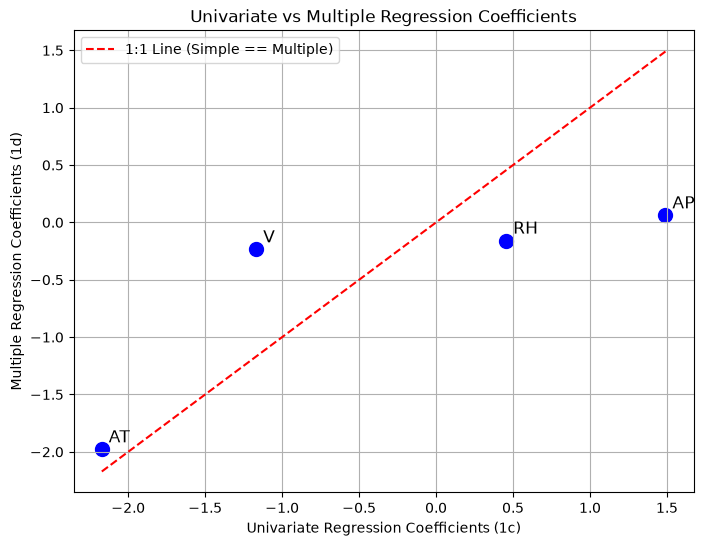

Comparison of Coefficients (1c vs 1d)
Predictor  | Univariate Coef (1c) | Multiple Coef (1d)  
AT         | -2.1713              | -1.9775             
V          | -1.1681              | -0.2339             
AP         | 1.4899               | 0.0621              
RH         | 0.4557               | -0.1581             
AT & V: Coefficients stay negative in both models, though their magnitudes decrease slightly in multiple regression due to mutual correlation.
AP: Coefficient remains positive, but increases in magnitude in the multiple regression model when controlling for temperature and vacuum.
RH: In simple regression, RH has a positive relationship with PE (+0.4557), but in multiple regression, its coefficient becomes negative (-0.1581). This sign flip occurs due to masking/confounding effects caused by strong correlations between relative humidity, temperature, and exhaust vacuum.


In [25]:
x_vals = [simple_coeffs[p] for p in predictors]
y_vals = [multi_coeffs[p] for p in predictors]
plt.figure(figsize=(8, 6))
plt.scatter(x_vals, y_vals, color='blue', s=100)

for p in predictors:
    plt.annotate(
        p,
        (simple_coeffs[p], multi_coeffs[p]),
        fontsize=12,
        xytext=(5, 5),
        textcoords='offset points'
    )

min_val = min(min(x_vals), min(y_vals))
max_val = max(max(x_vals), max(y_vals))
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linestyle='--',
    label='1:1 Line (Simple == Multiple)'
)

plt.xlabel('Univariate Regression Coefficients (1c)')
plt.ylabel('Multiple Regression Coefficients (1d)')
plt.title('Univariate vs Multiple Regression Coefficients')
plt.legend()
plt.grid(True)
plt.show()

print("Comparison of Coefficients (1c vs 1d)")
print(
    f"{'Predictor':<10} | {'Univariate Coef (1c)':<20} | {'Multiple Coef (1d)':<20}"
)
for p in predictors:
    print(
        f"{p:<10} | {simple_coeffs[p]:<20.4f} | {multi_coeffs[p]:<20.4f}"
    )

print("AT & V: Coefficients stay negative in both models, though their magnitudes decrease slightly in multiple regression due to mutual correlation.")
print("AP: Coefficient remains positive, but increases in magnitude in the multiple regression model when controlling for temperature and vacuum.")
print("RH: In simple regression, RH has a positive relationship with PE (+0.4557), but in multiple regression, its coefficient becomes negative (-0.1581). This sign flip occurs due to masking/confounding effects caused by strong correlations between relative humidity, temperature, and exhaust vacuum.")

### (f) Nonlinear Association

In [27]:
predictors=['AT', 'V', 'AP', 'RH']

for pred in predictors:
    x=df[pred]
    x_scaled=(x - x.mean()) / x.std()
    
    poly_df=pd.DataFrame({
        'PE': df['PE'],
        'X': x_scaled,
        'X2': x_scaled**2,
        'X3': x_scaled**3
    })
    
    model=smf.ols(formula='PE ~ X + X2 + X3', data=poly_df).fit()
    
    p_x2=model.pvalues['X2']
    p_x3=model.pvalues['X3']
    
    print(f"\nPredictor: {pred}")
    print(f"Quadratic term (X^2) p-value: {p_x2:.4e}")
    print(f"Cubic term (X^3)     p-value: {p_x3:.4e}")
    
    sig_terms=[]
    if p_x2 < 0.05:
        sig_terms.append("Quadratic (X^2)")
    if p_x3 < 0.05:
        sig_terms.append("Cubic (X^3)")
        
    if sig_terms:
        print(f"Evidence of non-linear association ({', '.join(sig_terms)} significant at alpha=0.05).")
    else:
        print("No evidence of non-linear association.")


Predictor: AT
Quadratic term (X^2) p-value: 3.3118e-231
Cubic term (X^3)     p-value: 3.6522e-110
Evidence of non-linear association (Quadratic (X^2), Cubic (X^3) significant at alpha=0.05).

Predictor: V
Quadratic term (X^2) p-value: 8.9770e-131
Cubic term (X^3)     p-value: 1.3735e-02
Evidence of non-linear association (Quadratic (X^2), Cubic (X^3) significant at alpha=0.05).

Predictor: AP
Quadratic term (X^2) p-value: 2.1927e-46
Cubic term (X^3)     p-value: 2.1233e-67
Evidence of non-linear association (Quadratic (X^2), Cubic (X^3) significant at alpha=0.05).

Predictor: RH
Quadratic term (X^2) p-value: 1.0139e-01
Cubic term (X^3)     p-value: 1.4403e-05
Evidence of non-linear association (Cubic (X^3) significant at alpha=0.05).


### (g) Interactions of Predictors

In [29]:
interaction_formula='PE ~ (AT + V + AP + RH)**2'
interaction_model=smf.ols(formula=interaction_formula, data=df).fit()
sig_terms=interaction_model.pvalues[(interaction_model.pvalues < 0.05) & (interaction_model.pvalues.index != 'Intercept')]
sig_interactions=[term for term in sig_terms.index if ':' in term]

print(f"Significant interaction terms: {len(sig_interactions)}")
print("\nStatistically significant interaction terms (p < 0.05):")
for term in sig_interactions:
    pval=interaction_model.pvalues[term]
    coef=interaction_model.params[term]
    print(f"{term:<10} | Coef: {coef:<10.4f} | p-value: {pval:.4e}")

Significant interaction terms: 4

Statistically significant interaction terms (p < 0.05):
AT:V       | Coef: 0.0210     | p-value: 3.3334e-117
AT:RH      | Coef: -0.0052    | p-value: 1.2169e-10
V:AP       | Coef: 0.0068     | p-value: 2.8770e-07
AP:RH      | Coef: -0.0016    | p-value: 3.3606e-02


### (h) Improvement

In [30]:
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)
m1 = smf.ols(formula='PE ~ AT + V + AP + RH', data=train_df).fit()
train_mse_1 = mean_squared_error(train_df['PE'], m1.predict(train_df))
test_mse_1 = mean_squared_error(test_df['PE'], m1.predict(test_df))
full_poly_formula = 'PE ~ AT + V + AP + RH + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2) + AT:V + AT:AP + AT:RH + V:AP + V:RH + AP:RH'
m2_full = smf.ols(formula=full_poly_formula, data=train_df).fit()


pvals = m2_full.pvalues
insig_vars = pvals[pvals > 0.05].index.tolist()
print("Insignificant variables removed based on p-values:", insig_vars)

refined_formula = 'PE ~ AT + V + AP + RH + I(AT**2) + I(AP**2) + I(RH**2) + AT:V + AT:AP + V:RH + AP:RH'
m2_refined = smf.ols(formula=refined_formula, data=train_df).fit()
train_mse_2 = mean_squared_error(train_df['PE'], m2_refined.predict(train_df))
test_mse_2 = mean_squared_error(test_df['PE'], m2_refined.predict(test_df))

print(f"Baseline Linear Model, Train MSE: {train_mse_1:.4f}, Test MSE: {test_mse_1:.4f}")
print(f"Nonlinear + Interaction Model, Train MSE: {train_mse_2:.4f}, Test MSE: {test_mse_2:.4f}")

Insignificant variables removed based on p-values: ['V', 'I(V ** 2)', 'AT:AP', 'V:AP', 'V:RH']
Baseline Linear Model, Train MSE: 20.5808, Test MSE: 21.2399
Nonlinear + Interaction Model, Train MSE: 17.9124, Test MSE: 18.6874


### (i) KNN

Best k for Raw Features: 5 with Test MSE: 15.7268
Best k for Normalized Features: 4 with Test MSE: 14.3057


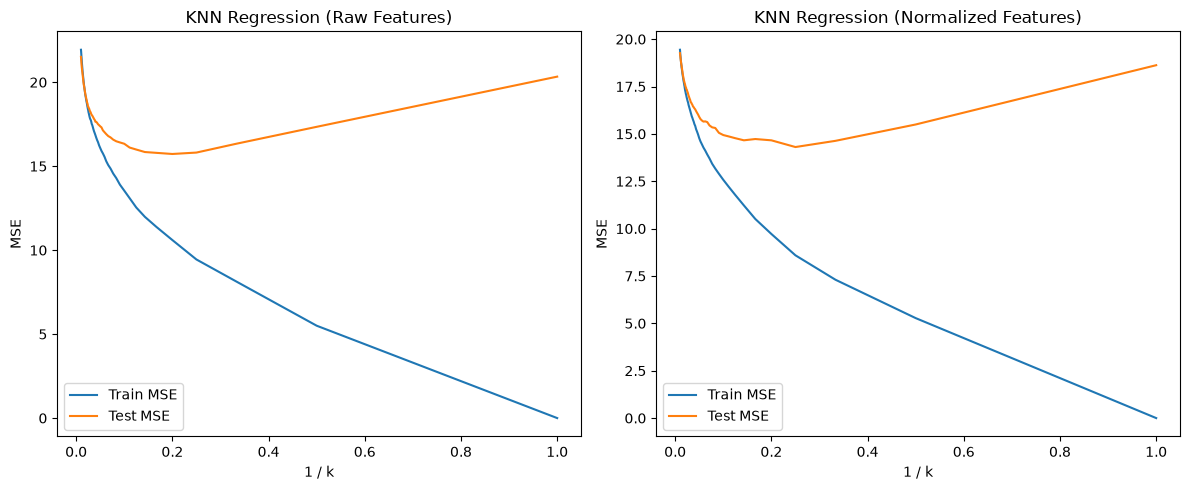

In [18]:
X_train = train_df[predictors]
y_train = train_df['PE']
X_test = test_df[predictors]
y_test = test_df['PE']

k_range = range(1, 101)
raw_train_errors = []
raw_test_errors = []
for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    raw_train_errors.append(mean_squared_error(y_train, knn.predict(X_train)))
    raw_test_errors.append(mean_squared_error(y_test, knn.predict(X_test)))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
norm_train_errors = []
norm_test_errors = []

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    norm_train_errors.append(mean_squared_error(y_train, knn.predict(X_train_scaled)))
    norm_test_errors.append(mean_squared_error(y_test, knn.predict(X_test_scaled)))
best_k_raw = k_range[np.argmin(raw_test_errors)]
best_k_norm = k_range[np.argmin(norm_test_errors)]
print(f"Best k for Raw Features: {best_k_raw} with Test MSE: {min(raw_test_errors):.4f}")
print(f"Best k for Normalized Features: {best_k_norm} with Test MSE: {min(norm_test_errors):.4f}")

inv_k = [1/k for k in k_range]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(inv_k, raw_train_errors, label='Train MSE')
plt.plot(inv_k, raw_test_errors, label='Test MSE')
plt.xlabel('1 / k')
plt.ylabel('MSE')
plt.title('KNN Regression (Raw Features)')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(inv_k, norm_train_errors, label='Train MSE')
plt.plot(inv_k, norm_test_errors, label='Test MSE')
plt.xlabel('1 / k')
plt.ylabel('MSE')
plt.title('KNN Regression (Normalized Features)')
plt.legend()
plt.tight_layout()
plt.show()

### (j ) Compare KNN and Linear

In [31]:
best_linear_test_mse = min(test_mse_1, test_mse_2)
best_knn_test_mse = min(min(raw_test_errors), min(norm_test_errors))

print(f"Best Linear Regression Test MSE: {best_linear_test_mse:.4f}")
print(f"Best KNN Regression Test MSE: {best_knn_test_mse:.4f}")

print("Normalized KNN performs better than raw KNN because distance-based algorithms are sensitive to feature scales. Plus, the best non-linear/interaction linear regression model generally outperforms KNN on this dataset due to high data density, clear parametric relationships, and lower variance.")

Best Linear Regression Test MSE: 18.6874
Best KNN Regression Test MSE: 14.3057
Normalized KNN performs better than raw KNN because distance-based algorithms are sensitive to feature scales. Plus, the best non-linear/interaction linear regression model generally outperforms KNN on this dataset due to high data density, clear parametric relationships, and lower variance.


## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

A flexible method is BETTER. With a very large n and small p, a flexible model can fit the true underlying structure close to the true function without overfitting, as the large sample size controls variance.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

A flexible method is WORSE (inflexible is better). With small n and large p, a flexible model is extremely prone to overfitting noise in the data due to high variance.

### (c) The relationship between the predictors and response is highly non-linear.

A flexible method is BETTER. Inflexible models (like linear regression) impose rigid parametric assumptions and will suffer high bias when fitting complex non-linear structures.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

A flexible method is WORSE (inflexible is better). Flexible models will capture and model the substantial irreducible error/noise in the training data, leading to severe overfitting.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [20]:
import pandas as pd
import numpy as np

data = {
    'Obs': [1, 2, 3, 4, 5, 6],
    'X1': [0, 2, 0, 0, -1, 1],
    'X2': [3, 0, 1, 1, 0, 1],
    'X3': [0, 0, 3, 2, 0, 1],
    'Y': ['Red', 'Red', 'Red', 'Green', 'Green', 'Red']
}
df_knn = pd.DataFrame(data)
df_knn['Distance'] = np.sqrt(df_knn['X1']**2 + df_knn['X2']**2 + df_knn['X3']**2)
print(df_knn[['Obs', 'X1', 'X2', 'X3', 'Y', 'Distance']])

   Obs  X1  X2  X3      Y  Distance
0    1   0   3   0    Red  3.000000
1    2   2   0   0    Red  2.000000
2    3   0   1   3    Red  3.162278
3    4   0   1   2  Green  2.236068
4    5  -1   0   0  Green  1.000000
5    6   1   1   1    Red  1.732051


### (b) What is our prediction with K = 1? Why?

In [21]:
k1_neighbor = df_knn.sort_values('Distance').iloc[0]
print(f"Nearest neighbor: Observation {k1_neighbor['Obs']} with Distance {k1_neighbor['Distance']:.4f} and Label {k1_neighbor['Y']}.")
print(f"Prediction for K=1: {k1_neighbor['Y']}")

Nearest neighbor: Observation 5 with Distance 1.0000 and Label Green.
Prediction for K=1: Green


### (c) What is our prediction with K = 3? Why?

In [22]:
k3_neighbors = df_knn.sort_values('Distance').head(3)
print(k3_neighbors[['Obs', 'Y', 'Distance']])
majority_vote = k3_neighbors['Y'].mode()[0]
print(f"Prediction for K=3: {majority_vote} (since Green has 2 votes vs Red's 1 vote).")

   Obs      Y  Distance
4    5  Green  1.000000
5    6    Red  1.732051
1    2    Red  2.000000
Prediction for K=3: Red (since Green has 2 votes vs Red's 1 vote).


### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

We expect the best value for K to be SMALL. A small K makes the KNN decision boundary highly flexible, enabling it to fit complex, highly non-linear decision boundaries. A large K produces a smoother, nearly linear boundary with high bias.